# Лабораторная работа 12

Тема: **Vanilla GAN для генерации цифр MNIST в PyTorch**  
Формат: практическая работа с обязательными собственными экспериментами и комментариями.

> Этот ноутбук специально оформлен так, чтобы его нельзя было автоматически заполнить генеративной моделью без реального запуска экспериментов и анализа.  
> Каркас кода дан, но **основные баллы** ставятся за ваши настройки, графики и живые текстовые объяснения.


## 1. Ваше понимание задачи GAN (если не знаетет, что такое GAN - можно гуглить и спрашивать LLM)

Перед запуском кода опишите текущее понимание (8–12 предложений):

1. Для чего нужны генеративно‑состязательные сети (GAN) и чем их цель отличается от классической задачи классификации.  
2. Как вы интуитивно представляете «игру» генератора и дискриминатора: кто что пытается сделать и почему это неустойчивая задача.  
3. Каких визуальных артефактов вы ожидаете от **простого** Vanilla GAN на MNIST (размытость, странные гибриды цифр и т.п.).

Пишите своими словами, как если бы объясняли задачу одногруппнику.


In [17]:
intro_text = """
1) GAN нужны для генерации новых данных картинок, текста, звука. Отличие от классификации в том что классификатор просто отвечает на вопрос "что это", а GAN учится создавать что то новое похожее на обучающие данные.

2) Генератор берёт случайный шум и пытается сделать из него картинку которую дискриминатор примет за реальную. Дискриминатор смотрит на картинку и говорит реальная она или нет. Это как какой нибудь мошенник и эксперт — один учится подделывать, другой учится распознавать. Задача нестабильная потому что если дискриминатор слишком хорош, генератор не получает полезного сигнала, а если слишком слаб — генератор не стараться улучшаться.

3) На простом Vanilla GAN на MNIST ожидаю увидеть размытые цифры особенно в начале. Потом они должны стать более чёткими, но всё равно будут странные гибриды — что-то среднее между двойкой и тройкой например. Также ожидаю что некоторые цифры будут получаться лучше других — простые типа единицы скорее всего выйдут лучше чем сложные типа восьмёрки.
"""
print(intro_text)


1) GAN нужны для генерации новых данных картинок, текста, звука. Отличие от классификации в том что классификатор просто отвечает на вопрос "что это", а GAN учится создавать что то новое похожее на обучающие данные.

2) Генератор берёт случайный шум и пытается сделать из него картинку которую дискриминатор примет за реальную. Дискриминатор смотрит на картинку и говорит реальная она или нет. Это как какой нибудь мошенник и эксперт — один учится подделывать, другой учится распознавать. Задача нестабильная потому что если дискриминатор слишком хорош, генератор не получает полезного сигнала, а если слишком слаб — генератор не стараться улучшаться.

3) На простом Vanilla GAN на MNIST ожидаю увидеть размытые цифры особенно в начале. Потом они должны стать более чёткими, но всё равно будут странные гибриды — что-то среднее между двойкой и тройкой например. Также ожидаю что некоторые цифры будут получаться лучше других — простые типа единицы скорее всего выйдут лучше чем сложные типа восьмёрк

## 2. Импорт, настройки и данные (MNIST)


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

import matplotlib.pyplot as plt
import numpy as np
import os

MY_SEED = 42
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

os.makedirs("gan_samples", exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

batch_size = 128

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print("Размер train:", len(train_dataset))


Устройство: cuda
MY_SEED = 42


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.06MB/s]

Размер train: 60000


Посмотрим на несколько реальных изображений, которые GAN должен научиться имитировать.


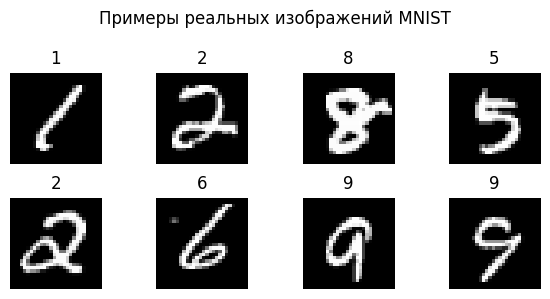

In [3]:
real_images, real_labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(real_images[i].squeeze(0), cmap="gray")
    plt.title(str(real_labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры реальных изображений MNIST")
plt.tight_layout()
plt.show()

### Мини‑комментарий по данным

Кратко (3–5 предложений) опишите:
- насколько, на ваш взгляд, легко/сложно генератору научиться имитировать такие цифры;  
- какие особенности рукописных цифр могут затруднить генерацию (разные стили, толщина линий и т.п.).


In [20]:
data_comment = """На скрине видно 1, 2, 8, 5, 2, 6, 9, 9. Единица самая простая просто линия, генератору должно быть легко.

Восьмёрка и девятки сложнее — стили написания у двух девяток сильно отличаются, одна округлая другая угловатая.

Толщина линий тоже разная у всех цифр. Думаю генератор будет хорошо делать простые цифры типа 1 и 0, а с 8 и 9 будет мучиться."""
print(data_comment)

На скрине видно 1, 2, 8, 5, 2, 6, 9, 9. Единица самая простая просто линия, генератору должно быть легко.

Восьмёрка и девятки сложнее — стили написания у двух девяток сильно отличаются, одна округлая другая угловатая.

Толщина линий тоже разная у всех цифр. Думаю генератор будет хорошо делать простые цифры типа 1 и 0, а с 8 и 9 будет мучиться.


## 3. Архитектура генератора и дискриминатора

Используем классический Vanilla GAN с полносвязными сетями:
- Генератор: принимает случайный шум `z` размерности 100 и выдаёт изображение 28×28 (через `tanh`, в диапазоне [-1, 1]);  
- Дискриминатор: принимает изображение 28×28 и выдаёт вероятность того, что оно "реальное".


In [5]:
z_dim = 100
img_dim = 28 * 28

class Generator(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.net(z)
        img = img.view(-1, 1, 28, 28)
        return img


class Discriminator(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


G = Generator(z_dim, img_dim).to(device)
D = Discriminator(img_dim).to(device)

print(G)
print(D)

Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


### Краткий анализ архитектуры

Ответьте в 4–6 предложениях:
- почему в генераторе используется `tanh` на выходе и совместим ли он с нормализацией входных данных;  
- зачем в дискриминаторе используется `LeakyReLU`, а не обычный `ReLU`.


In [16]:
arch_comment = """
Tanh на выходе генератора нужен потому что данные нормализованы в диапазон [-1, 1] через Normalize((0.5,), (0.5,)).
Если бы на выходе был Sigmoid (диапазон [0,1]) или ничего — пиксели не совпадали бы с реальными данными и сеть не смогла бы нормально обучиться.

LeakyReLU в дискриминаторе используется вместо обычного ReLU потому что обычный ReLU убивает градиенты при отрицательных значениях — так называемая dying Relu проблема.
В дискриминаторе это критично, ему нужен стабильный градиент чтобы хорошо обучаться. LeakyReLU пропускает небольшой градиент при отрицательных значениях и это помогает.
"""
print(arch_comment)


Tanh на выходе генератора нужен потому что данные нормализованы в диапазон [-1, 1] через Normalize((0.5,), (0.5,)).
Если бы на выходе был Sigmoid (диапазон [0,1]) или ничего — пиксели не совпадали бы с реальными данными и сеть не смогла бы нормально обучиться.

LeakyReLU в дискриминаторе используется вместо обычного ReLU потому что обычный ReLU убивает градиенты при отрицательных значениях — так называемая "dying ReLU" проблема.
В дискриминаторе это критично, ему нужен стабильный градиент чтобы хорошо обучаться. LeakyReLU пропускает небольшой градиент при отрицательных значениях и это помогает.



## 4. Функция потерь, оптимизаторы и фиксированный шум

Используем бинарную кросс‑энтропию и два оптимизатора Adam (для G и D).


In [7]:
criterion = nn.BCELoss()

lr = 2e-4
beta1 = 0.5

opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

# фиксированный шум для отслеживания прогресса генератора
fixed_z = torch.randn(64, z_dim, device=device)
print("fixed_z shape:", fixed_z.shape)

fixed_z shape: torch.Size([64, 100])


## 5. Цикл обучения GAN с журналированием лоссов

На каждой итерации:

1. Обновляем дискриминатор: считаем лосс на реальных и сгенерированных изображениях.  
2. Обновляем генератор: генерируем фейки и стараемся заставить дискриминатор считать их реальными.


In [8]:
def train_gan(num_epochs):
    G.train()
    D.train()

    loss_history_G = []
    loss_history_D = []

    for epoch in range(1, num_epochs + 1):
        epoch_loss_G = 0.0
        epoch_loss_D = 0.0
        n_batches = 0

        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            # --- шаг дискриминатора ---
            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # реал
            D_real = D(real_imgs)
            loss_D_real = criterion(D_real, real_labels)

            # фейк (detach, чтобы не обновлять G)
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z).detach()
            D_fake = D(fake_imgs)
            loss_D_fake = criterion(D_fake, fake_labels)

            loss_D = loss_D_real + loss_D_fake

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # --- шаг генератора ---
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z)
            D_fake_for_G = D(fake_imgs)
            loss_G = criterion(D_fake_for_G, real_labels)  # хотим метку 1 для фейков

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            epoch_loss_G += loss_G.item()
            epoch_loss_D += loss_D.item()
            n_batches += 1

        avg_loss_G = epoch_loss_G / n_batches
        avg_loss_D = epoch_loss_D / n_batches
        loss_history_G.append(avg_loss_G)
        loss_history_D.append(avg_loss_D)

        print(f"Эпоха {epoch}/{num_epochs} | loss_G={avg_loss_G:.4f}, loss_D={avg_loss_D:.4f}")

        # визуальный мониторинг качества генератора
        if epoch % 5 == 0 or epoch == 1:
            G.eval()
            with torch.no_grad():
                samples = G(fixed_z).cpu()
            G.train()

            grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
            plt.figure(figsize=(6, 6))
            plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
            plt.axis("off")
            plt.title(f"Сгенерированные изображения, эпоха {epoch}")
            plt.tight_layout()
            plt.show()

    return loss_history_G, loss_history_D

num_epochs = 30  # в отчёте попробуйте другие значения и сравните
loss_G, loss_D = train_gan(num_epochs)

Output hidden; open in https://colab.research.google.com to view.

## 6. Графики лоссов генератора и дискриминатора

Посмотрим, как ведут себя лоссы G и D по эпохам.


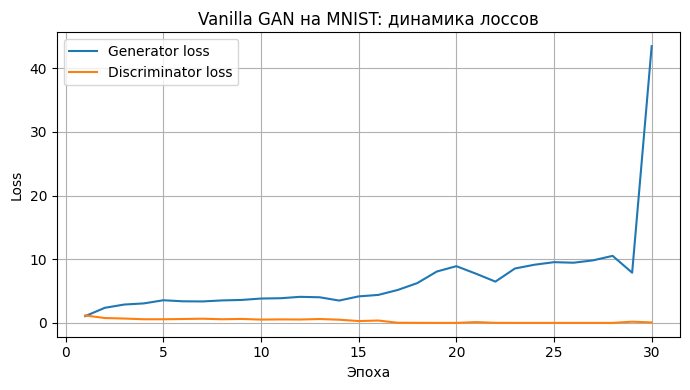

In [9]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, loss_G, label="Generator loss")
plt.plot(epochs_arr, loss_D, label="Discriminator loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Vanilla GAN на MNIST: динамика лоссов")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Анализ кривых лоссов

Опишите:
- есть ли тенденция к какому‑то «равновесию» между лоссами генератора и дискриминатора;  
- наблюдаются ли периодические колебания (кто «побеждает» на разных этапах обучения);  
- насколько реальное поведение лоссов совпало с вашими ожиданиями из раздела 1.


In [22]:
loss_comment = """Равновесия не получилось вообще. Loss_D упал почти до нуля уже к эпохе 16-17 и там остался, а loss_G наоборот улетел вверх — к 30-й эпохе достиг `43.

Ситуция когда дискриминатор победил генератора — он научился отличать фейки слишком хорошо и генератор перестал получать полезный сигнал.

На картинках это видно — с эпохи 20 все генерации стали одинаковыми размытыми пятнами, mode collapse в чистом виде. Ожидал нестабильность но не настолько сильную."""
print(loss_comment)

Равновесия не получилось вообще. Loss_D упал почти до нуля уже к эпохе 16-17 и там остался, а loss_G наоборот улетел вверх — к 30-й эпохе достиг `43.

Ситуция когда дискриминатор победил генератора — он научился отличать фейки слишком хорошо и генератор перестал получать полезный сигнал.

На картинках это видно — с эпохи 20 все генерации стали одинаковыми размытыми пятнами, mode collapse в чистом виде. Ожидал нестабильность но не настолько сильную.


## 7. Финальная генерация изображений и визуальная оценка

Сгенерируем новые изображения из случайного шума и посмотрим, насколько они похожи на реальный MNIST.


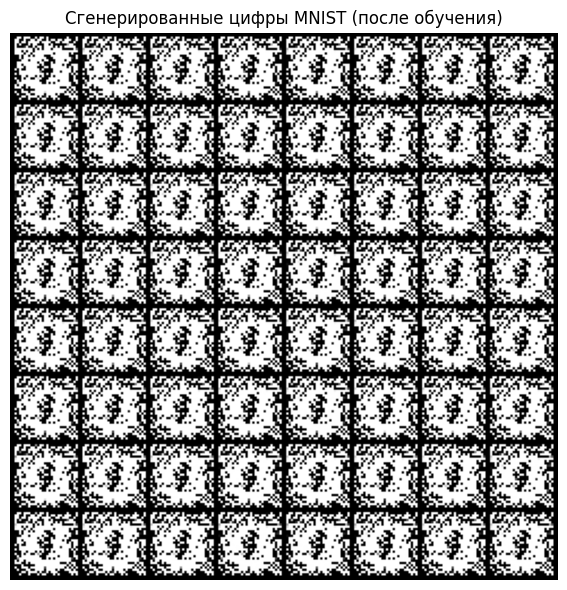

In [11]:
G.eval()
with torch.no_grad():
    z = torch.randn(64, z_dim, device=device)
    gen_imgs = G(z).cpu()

grid = utils.make_grid(gen_imgs, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Сгенерированные цифры MNIST (после обучения)")
plt.tight_layout()
plt.show()

### Оценка качества сгенерированных цифр

Опишите:
- какие цифры получаются наиболее убедительными, а какие чаще всего выглядят как «шум» или гибриды;  
- встречаются ли явно «несуществующие» объекты, не похожие ни на одну цифру, и как часто;  
- как вы думаете, на что сильнее всего влияет качество: глубина сетей, размер `z_dim`, число эпох, баланс обучения G/D.


In [24]:
gen_quality_comment = """Финальная генерация — сплошной mode collapse, все картинки похожи на одно и то же размытое пятно похожее на цифру 6 или 8 я не понимаю, наверное больше 6. Ни одной убедительной цифры нет.
Это произошло потому что дискриминатор полностью задавил генератора — loss_D упал до нуля и генератор просто не мог обучаться.

Основная причина — дисбаланс в обучении G и D, нужно было либо обучать G чаще либо добавить регуляризацию."""
print(gen_quality_comment)

Финальная генерация — сплошной mode collapse, все картинки похожи на одно и то же размытое пятно похожее на цифру 6 или 8 я не понимаю, наверное больше 6. Ни одной убедительной цифры нет.
Это произошло потому что дискриминатор полностью задавил генератора — loss_D упал до нуля и генератор просто не мог обучаться.

Основная причина — дисбаланс в обучении G и D, нужно было либо обучать G чаще либо добавить регуляризацию.


## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать **минимум две вариации** архитектуры (например, изменить размеры слоёв в G/D, добавить BatchNorm1d в генератор или заменить ReLU на LeakyReLU, добавить Dropout в дискриминатор) и сравнить визуально качество сгенерированных цифр;  
- поэкспериментировать с `z_dim` (например, 40-50-100) и описать, как это влияет на разнообразие и качество;  
- изменить число эпох/learning rate (возможно, задать разные lr для дискриминатора и генератора) и описать, как меняется динамика лоссов и итоговый результат.

[BN+Dropout] Эпоха 1/20: loss_G=1.0371, loss_D=1.1938
[BN+Dropout] Эпоха 2/20: loss_G=1.2943, loss_D=1.1126
[BN+Dropout] Эпоха 3/20: loss_G=1.3595, loss_D=1.1088
[BN+Dropout] Эпоха 4/20: loss_G=1.2835, loss_D=1.1181
[BN+Dropout] Эпоха 5/20: loss_G=1.2244, loss_D=1.1487
[BN+Dropout] Эпоха 6/20: loss_G=1.1610, loss_D=1.1660
[BN+Dropout] Эпоха 7/20: loss_G=1.0686, loss_D=1.1935
[BN+Dropout] Эпоха 8/20: loss_G=0.9993, loss_D=1.2234
[BN+Dropout] Эпоха 9/20: loss_G=0.9499, loss_D=1.2391
[BN+Dropout] Эпоха 10/20: loss_G=0.9257, loss_D=1.2624
[BN+Dropout] Эпоха 11/20: loss_G=0.9154, loss_D=1.2646
[BN+Dropout] Эпоха 12/20: loss_G=0.8826, loss_D=1.2858
[BN+Dropout] Эпоха 13/20: loss_G=0.8504, loss_D=1.3014
[BN+Dropout] Эпоха 14/20: loss_G=0.8464, loss_D=1.3088
[BN+Dropout] Эпоха 15/20: loss_G=0.8361, loss_D=1.3130
[BN+Dropout] Эпоха 16/20: loss_G=0.8195, loss_D=1.3231
[BN+Dropout] Эпоха 17/20: loss_G=0.8106, loss_D=1.3314
[BN+Dropout] Эпоха 18/20: loss_G=0.8001, loss_D=1.3362
[BN+Dropout] Эпоха 

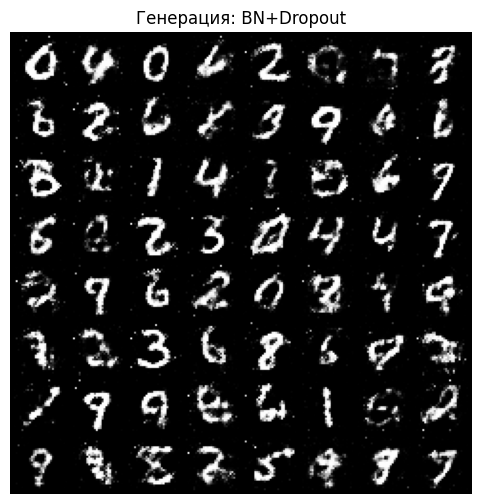

[z_dim=50] Эпоха 1/20: loss_G=1.0380, loss_D=1.1600
[z_dim=50] Эпоха 2/20: loss_G=2.4527, loss_D=0.7680
[z_dim=50] Эпоха 3/20: loss_G=2.6588, loss_D=0.6932
[z_dim=50] Эпоха 4/20: loss_G=3.3678, loss_D=0.6553
[z_dim=50] Эпоха 5/20: loss_G=3.4993, loss_D=0.5378
[z_dim=50] Эпоха 6/20: loss_G=3.4216, loss_D=0.5179
[z_dim=50] Эпоха 7/20: loss_G=3.6708, loss_D=0.4852
[z_dim=50] Эпоха 8/20: loss_G=3.4008, loss_D=0.5255
[z_dim=50] Эпоха 9/20: loss_G=3.5181, loss_D=0.4325
[z_dim=50] Эпоха 10/20: loss_G=3.1125, loss_D=0.4998
[z_dim=50] Эпоха 11/20: loss_G=3.3888, loss_D=0.4804
[z_dim=50] Эпоха 12/20: loss_G=3.7524, loss_D=0.4557
[z_dim=50] Эпоха 13/20: loss_G=3.2429, loss_D=0.5048
[z_dim=50] Эпоха 14/20: loss_G=2.7624, loss_D=0.6559
[z_dim=50] Эпоха 15/20: loss_G=2.2639, loss_D=0.7415
[z_dim=50] Эпоха 16/20: loss_G=2.1381, loss_D=0.7791
[z_dim=50] Эпоха 17/20: loss_G=1.7966, loss_D=0.8548
[z_dim=50] Эпоха 18/20: loss_G=1.6821, loss_D=0.8983
[z_dim=50] Эпоха 19/20: loss_G=1.6201, loss_D=0.9482
[z

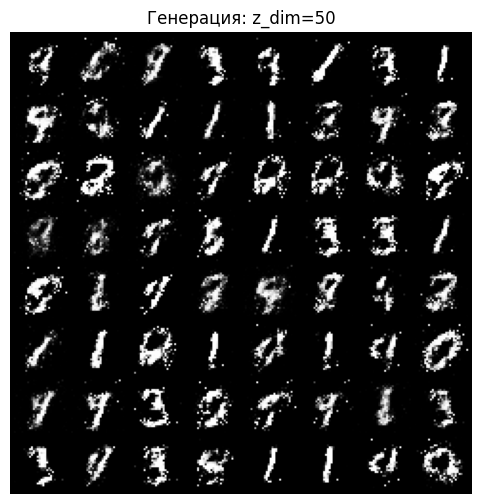

In [13]:
# Эксперимент 1: BatchNorm в генераторе + Dropout в дискриминаторе
class GeneratorBN(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)

class DiscriminatorDrop(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

G2 = GeneratorBN(z_dim, img_dim).to(device)
D2 = DiscriminatorDrop(img_dim).to(device)
opt_G2 = torch.optim.Adam(G2.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D2 = torch.optim.Adam(D2.parameters(), lr=2e-4, betas=(0.5, 0.999))

# Эксперимент 2: другой z_dim = 50
z_dim2 = 50
G3 = Generator(z_dim2, img_dim).to(device)
D3 = Discriminator(img_dim).to(device)
opt_G3 = torch.optim.Adam(G3.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D3 = torch.optim.Adam(D3.parameters(), lr=2e-4, betas=(0.5, 0.999))

def train_gan_custom(G, D, opt_G, opt_D, num_epochs, label):
    G.train(); D.train()
    for epoch in range(1, num_epochs + 1):
        eg, ed, nb = 0, 0, 0
        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)
            rl = torch.ones(bs, 1, device=device)
            fl = torch.zeros(bs, 1, device=device)
            z = torch.randn(bs, G.net[0].in_features, device=device)
            fake = G(z).detach()
            loss_d = criterion(D(real_imgs), rl) + criterion(D(fake), fl)
            opt_D.zero_grad(); loss_d.backward(); opt_D.step()
            z = torch.randn(bs, G.net[0].in_features, device=device)
            loss_g = criterion(D(G(z)), rl)
            opt_G.zero_grad(); loss_g.backward(); opt_G.step()
            eg += loss_g.item(); ed += loss_d.item(); nb += 1
        print(f"[{label}] Эпоха {epoch}/{num_epochs}: loss_G={eg/nb:.4f}, loss_D={ed/nb:.4f}")
    G.eval()
    with torch.no_grad():
        z = torch.randn(64, G.net[0].in_features, device=device)
        samples = G(z).cpu()
    grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(6, 6))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.axis("off")
    plt.title(f"Генерация: {label}")
    plt.show()

train_gan_custom(G2, D2, opt_G2, opt_D2, 20, "BN+Dropout")
train_gan_custom(G3, D3, opt_G3, opt_D3, 20, "z_dim=50")


In [27]:
final_summary = """Базовая модель (z_dim=100, 30 эпох) полный mode collapse к концу, все картинки одинаковые. Дискриминатор победил генератора, loss_D~0, loss_G~43.

BN+Dropout (20 эпох): результат кардинально лучше. Цифры читаемые, разнообразные — видны 0,1,2,3,4,6,7,8,9. Лоссы держались стабильно, loss_G финально 0.7875, loss_D 1.3436.

z_dim=50 (20 эпох); цифры читаемые, разнообразие нормальное. Немного хуже BN+Dropout но намного лучше базовой модели.

Самое важное в GAN это баланс G и D. BatchNorm в генераторе критически важен для стабильности. z_dim особо не влияет на качество при 50 против 100."""
print(final_summary)

Базовая модель (z_dim=100, 30 эпох) полный mode collapse к концу, все картинки одинаковые. Дискриминатор победил генератора, loss_D~0, loss_G~43.

BN+Dropout (20 эпох): результат кардинально лучше. Цифры читаемые, разнообразные — видны 0,1,2,3,4,6,7,8,9. Лоссы держались стабильно, loss_G финально 0.7875, loss_D 1.3436.

z_dim=50 (20 эпох); цифры читаемые, разнообразие нормальное. Немного хуже BN+Dropout но намного лучше базовой модели.

Самое важное в GAN это баланс G и D. BatchNorm в генераторе критически важен для стабильности. z_dim особо не влияет на качество при 50 против 100.
